In [4]:
%load_ext autoreload
%autoreload 2

In [16]:
## general libraries
import pathlib
from loguru import logger

## data handling libraries
import joblib
import numpy as np
import pandas as pd
import xarray as xr
from tqdm.dask import TqdmCallback as ProgressBarDask

# plotting libraries
import matplotlib.pyplot as plt
import hvplot.xarray
import panel

## machine learning libraries
import gpytorch 
import torch
import ngboost
from sklearn import metrics
from sklearn import ensemble as trees

## PAMIR libraries
import mlflow
import hydra
import pamir_mlpermafrost as pamir
from cryogrid_pytools import xr_raster_vector

ngb = pamir.models.ngb

In [6]:
cfg = pamir.utils.load_hydra_config(
    config_dir='../../src/pamir_mlpermafrost/conf', 
    config_name='ngboost')

2025-09-23 16:25:03 | WARNING  - Will pop `run_dir` since detected in Notebook and cant be resolved


In [52]:
data = ngb.main.load_training_data(cfg)
train = data.train
valid = data.valid
test = data.test

data.x = pd.concat([train.x, valid.x, test.x], axis=0)
data.y = pd.concat([train.y, valid.y, test.y], axis=0)

In [18]:
model_fname_template = "s3://spi-pamir-cryogrid/pamir-MLpermafrost/data-output/ngboost-single_depth-cv_tuning/pamir-ngboost-models/ground_temp_{season}_{depth}m.joblib_pkl"

In [60]:
season = 'JAS'
depth = 3
depth = str(depth).replace('.', '')

model_fname = model_fname_template.format(season=season, depth=depth)
model = pamir.data.s3_utils.open_file_local(model_fname, joblib.load)

(array([  3.,   3.,   4.,  13.,  11.,  25.,  18.,  18.,  38.,  46.,  40.,
         79., 118., 161., 195., 317., 389., 559., 804., 815., 640., 562.,
        542., 346., 446., 454., 396., 196.,  58.,  19.]),
 array([-16.36701451, -15.69184076, -15.01666701, -14.34149327,
        -13.66631952, -12.99114577, -12.31597202, -11.64079828,
        -10.96562453, -10.29045078,  -9.61527703,  -8.94010329,
         -8.26492954,  -7.58975579,  -6.91458205,  -6.2394083 ,
         -5.56423455,  -4.8890608 ,  -4.21388706,  -3.53871331,
         -2.86353956,  -2.18836581,  -1.51319207,  -0.83801832,
         -0.16284457,   0.51232917,   1.18750292,   1.86267667,
          2.53785042,   3.21302416,   3.88819791]),
 <BarContainer object of 30 artists>)

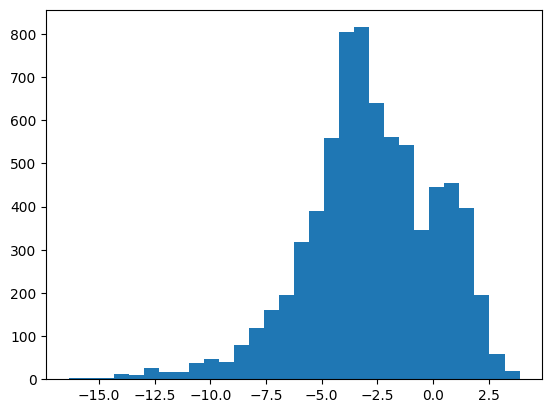

In [63]:
dist = model.pred_dist(data.x).dist
avg = dist.mean()
plt.hist(avg, bins=30)

(array([1284.,  281.,  145.,  143.,  106.,  142.,  117.,  138.,  125.,
         103.,   88.,   78.,   99.,   78.,  103.,  117.,   94.,  126.,
          87.,  137.,  146.,  145.,  174.,  213.,  288.,  289.,  341.,
         353.,  444., 1331.]),
 array([2.30794558e-07, 3.33335556e-02, 6.66668803e-02, 1.00000205e-01,
        1.33333530e-01, 1.66666855e-01, 2.00000179e-01, 2.33333504e-01,
        2.66666829e-01, 3.00000154e-01, 3.33333479e-01, 3.66666803e-01,
        4.00000128e-01, 4.33333453e-01, 4.66666778e-01, 5.00000102e-01,
        5.33333427e-01, 5.66666752e-01, 6.00000077e-01, 6.33333401e-01,
        6.66666726e-01, 7.00000051e-01, 7.33333376e-01, 7.66666701e-01,
        8.00000025e-01, 8.33333350e-01, 8.66666675e-01, 9.00000000e-01,
        9.33333324e-01, 9.66666649e-01, 9.99999974e-01]),
 <BarContainer object of 30 artists>)

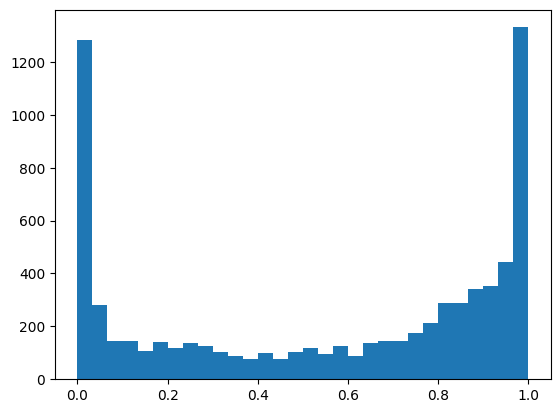

In [88]:
plt.hist(dist.cdf(-2.2), bins=30)